<b><font size="8">Classification | Diabetes Risk Prediction</font></b>
* **Purpose**: Build and evaluate 3 classification models (Decision Tree, Random Forest, XGBoost) to predict diabetes risk
* **Models**: Decision Tree, Random Forest, XGBoost

# 1.Importing Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import joblib
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)
print("Libraries imported successfully.")

Libraries imported successfully.


## 1.1 Project Root Navigation

**Current working directory:** `notebooks/`  
**Goal:** Access `data/processed/` from project root


In [ ]:
#Change to project directory (adjust path as needed)
project_dir = r"C:\Users\GontseM\Downloads\MLG382-Assignment1---Group-11-Gontse\MLG382-Assignment1---Group-11-Gontse"
os.chdir(project_dir)
print(f"✅ Now in: {os.getcwd()}")

✅ Now in: C:\Users\GontseM\Downloads\MLG382-Assignment1---Group-11-Gontse\MLG382-Assignment1---Group-11-Gontse


# 2. Load Data

Load the preprocessed training and test data prepared by Declin (Data Preprocessing).

In [ ]:
# Load the processed data
X_train = pd.read_csv('data/processed/X_train.csv')
X_test = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv')
y_test = pd.read_csv('data/processed/y_test.csv')

print(f"Data loaded successfully.")
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"\nTarget variable distribution (training):")
print(y_train.value_counts())

Data loaded successfully.
Training data shape: (68107, 39)
Test data shape: (14595, 39)

Target variable distribution (training):
diabetes_stage_encoded
4                         40713
2                         21709
1                          5416
0                           187
3                            82
Name: count, dtype: int64


# 3. Model 1: Decision Tree Classifier

A Decision Tree splits the data based on feature thresholds to classify patients into diabetes stages. It is simple and easy to interpret.

In [ ]:
print("MODEL 1: DECISION TREE CLASSIFIER")

# Create and train Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=10, #max_depth limits tree size to prevent overfitting
    min_samples_split=10,
    min_samples_leaf=5, #min_samples_split and min_samples_leaf control how small branches can be
    random_state=42
)

dt_model.fit(X_train, y_train)
print("Decision Tree trained")

MODEL 1: DECISION TREE CLASSIFIER
Decision Tree trained


DECISION TREE PERFORMANCE:
  Training Accuracy:  0.9207
  Test Accuracy:      0.9115
  Test Precision:     0.9197
  Test Recall:        0.9115
  Test F1-Score:      0.9105

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        40
           1       0.83      0.97      0.90      1161
           2       0.83      0.99      0.90      4652
           3       0.00      0.00      0.00        17
           4       0.99      0.87      0.92      8725

    accuracy                           0.91     14595
   macro avg       0.53      0.57      0.54     14595
weighted avg       0.92      0.91      0.91     14595



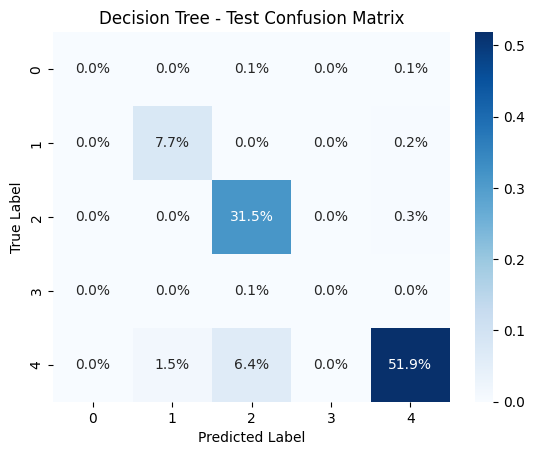

In [ ]:
#Generate predictions on both training and test sets
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

print("DECISION TREE PERFORMANCE:")
print(f"  Training Accuracy:  {accuracy_score(y_train, y_train_pred_dt):.4f}")
print(f"  Test Accuracy:      {accuracy_score(y_test, y_test_pred_dt):.4f}")
print(f"  Test Precision:     {precision_score(y_test, y_test_pred_dt, average='weighted', zero_division=0):.4f}")
print(f"  Test Recall:        {recall_score(y_test, y_test_pred_dt, average='weighted', zero_division=0):.4f}")
print(f"  Test F1-Score:      {f1_score(y_test, y_test_pred_dt, average='weighted', zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_dt))

# Confusion Matrix shows how often the model correctly vs incorrectly classified each stage
cm = confusion_matrix(y_test, y_test_pred_dt)
sns.heatmap(cm/np.sum(cm), annot=True, cmap='Blues', fmt='.1%')
plt.title('Decision Tree - Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

The training and test accuracy are close together, which suggests the model generalises well without memorising the training data. The confusion matrix shows the proportion of correct and incorrect predictions for each diabetes stage.

Top 10 Important Features (Decision Tree):
                               Feature  Importance
22                               hba1c    0.816450
19                     glucose_fasting    0.159996
3   physical_activity_minutes_per_week    0.002327
0                                  Age    0.002219
7              family_history_diabetes    0.002098
14                          heart_rate    0.001707
18                       triglycerides    0.001659
17                     ldl_cholesterol    0.001364
21                       insulin_level    0.001277
16                     hdl_cholesterol    0.001208


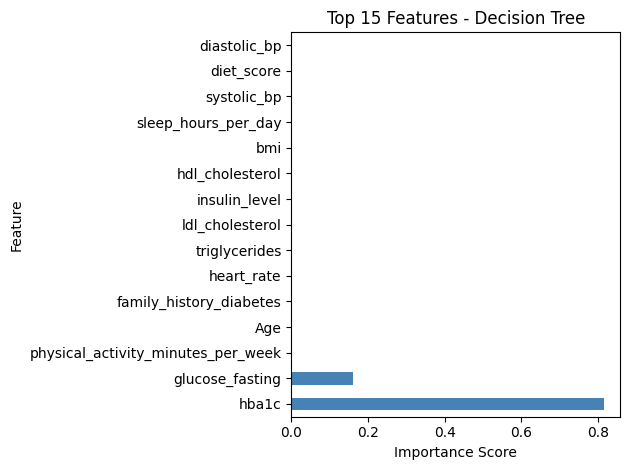

In [ ]:
# Rank features by how much they contributed to the model's decisions
dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Important Features (Decision Tree):")
print(dt_importance.head(10))

dt_importance.head(15).plot(kind='barh', x='Feature', y='Importance', color='steelblue', legend=False)
plt.title('Top 15 Features - Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [21]:
# Save model
joblib.dump(dt_model, 'artifacts\model_1.pkl')
print("Decision Tree model saved to artifacts\model_1.pkl")

Decision Tree model saved to artifacts\model_1.pkl


# 4. Model 2: Random Forest Classifier

Random Forest trains many decision trees on random subsets of the data and combines their predictions. This reduces overfitting and generally improves accuracy over a single tree.

In [22]:
print("MODEL 2: RANDOM FOREST CLASSIFIER")

# Create and train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
print("Random Forest trained")

MODEL 2: RANDOM FOREST CLASSIFIER


Random Forest trained


RANDOM FOREST PERFORMANCE:
  Training Accuracy:  0.9353
  Test Accuracy:      0.9154
  Test Precision:     0.9253
  Test Recall:        0.9154
  Test F1-Score:      0.9144

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        40
           1       0.83      1.00      0.91      1161
           2       0.83      1.00      0.90      4652
           3       0.00      0.00      0.00        17
           4       1.00      0.87      0.93      8725

    accuracy                           0.92     14595
   macro avg       0.53      0.57      0.55     14595
weighted avg       0.93      0.92      0.91     14595



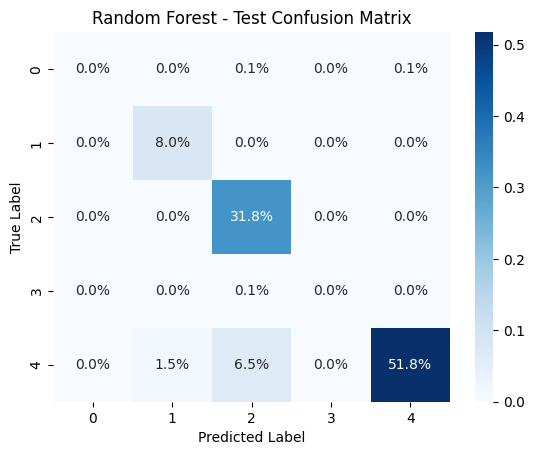

In [23]:
# Make predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluate
print("RANDOM FOREST PERFORMANCE:")
print(f"  Training Accuracy:  {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"  Test Accuracy:      {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"  Test Precision:     {precision_score(y_test, y_test_pred_rf, average='weighted', zero_division=0):.4f}")
print(f"  Test Recall:        {recall_score(y_test, y_test_pred_rf, average='weighted', zero_division=0):.4f}")
print(f"  Test F1-Score:      {f1_score(y_test, y_test_pred_rf, average='weighted', zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rf))

cm = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(cm/np.sum(cm), annot=True, cmap='Blues', fmt='.1%')
plt.title('Random Forest - Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Random Forest averages importance scores across all trees, making the rankings more reliable than a single Decision Tree.

Top 10 Important Features (Random Forest):
                               Feature  Importance
22                               hba1c    0.201445
19                     glucose_fasting    0.125226
0                                  Age    0.112682
20                glucose_postprandial    0.091029
1                               gender    0.043154
12                         systolic_bp    0.034567
10                                 bmi    0.028363
3   physical_activity_minutes_per_week    0.027496
6            screen_time_hours_per_day    0.026207
15                   cholesterol_total    0.026009


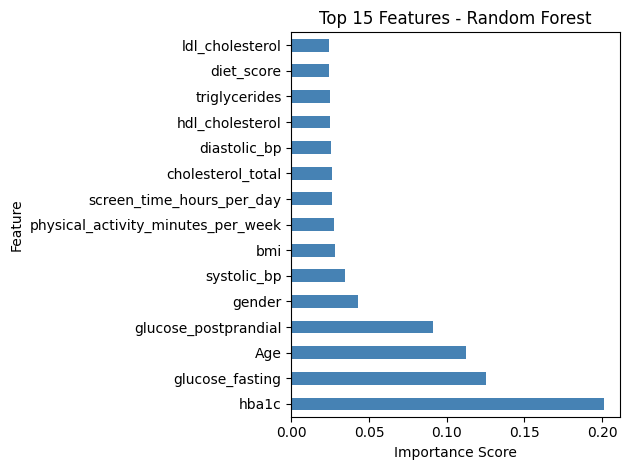

In [24]:
# Feature importance
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Important Features (Random Forest):")
print(rf_importance.head(10))

rf_importance.head(15).plot(kind='barh', x='Feature', y='Importance', color='steelblue', legend=False)
plt.title('Top 15 Features - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [25]:
# Save model
joblib.dump(rf_model, 'artifacts\model_2.pkl')
print("Random Forest model saved to artifacts\model_2.pkl")

Random Forest model saved to artifacts\model_2.pkl


# 5. Model 3: XGBoost Classifier

XGBoost builds trees sequentially, where each new tree corrects the errors of the previous one. It is one of the most powerful and widely used classification algorithms.

In [26]:
print("MODEL 3: XGBOOST CLASSIFIER")

# Create and train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)
print("XGBoost trained")

MODEL 3: XGBOOST CLASSIFIER
XGBoost trained



XGBOOST PERFORMANCE:
  Training Accuracy:  0.9185
  Test Accuracy:      0.9161
  Test Precision:     0.9261
  Test Recall:        0.9161
  Test F1-Score:      0.9152

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        40
           1       0.84      1.00      0.91      1161
           2       0.83      1.00      0.91      4652
           3       0.00      0.00      0.00        17
           4       1.00      0.87      0.93      8725

    accuracy                           0.92     14595
   macro avg       0.53      0.57      0.55     14595
weighted avg       0.93      0.92      0.92     14595



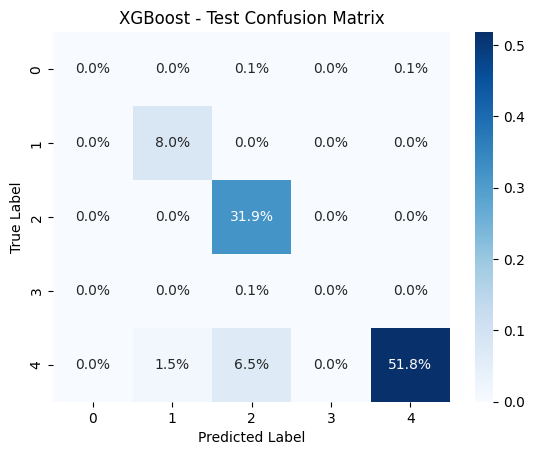

In [27]:
# Make predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("\nXGBOOST PERFORMANCE:")
print(f"  Training Accuracy:  {accuracy_score(y_train, y_train_pred_xgb):.4f}")
print(f"  Test Accuracy:      {accuracy_score(y_test, y_test_pred_xgb):.4f}")
print(f"  Test Precision:     {precision_score(y_test, y_test_pred_xgb, average='weighted', zero_division=0):.4f}")
print(f"  Test Recall:        {recall_score(y_test, y_test_pred_xgb, average='weighted', zero_division=0):.4f}")
print(f"  Test F1-Score:      {f1_score(y_test, y_test_pred_xgb, average='weighted', zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_xgb))

cm = confusion_matrix(y_test, y_test_pred_xgb)
sns.heatmap(cm/np.sum(cm), annot=True, cmap='Blues', fmt='.1%')
plt.title('XGBoost - Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

XGBoost importance scores reflect how often each feature was used to make a split across all trees.


Top 10 Important Features (XGBoost):
                               Feature  Importance
22                               hba1c    0.627506
19                     glucose_fasting    0.144425
20                glucose_postprandial    0.042444
7              family_history_diabetes    0.022863
1                               gender    0.012043
0                                  Age    0.009872
3   physical_activity_minutes_per_week    0.005359
26                     ethnicity_White    0.005134
23                     ethnicity_Black    0.004755
16                     hdl_cholesterol    0.004717


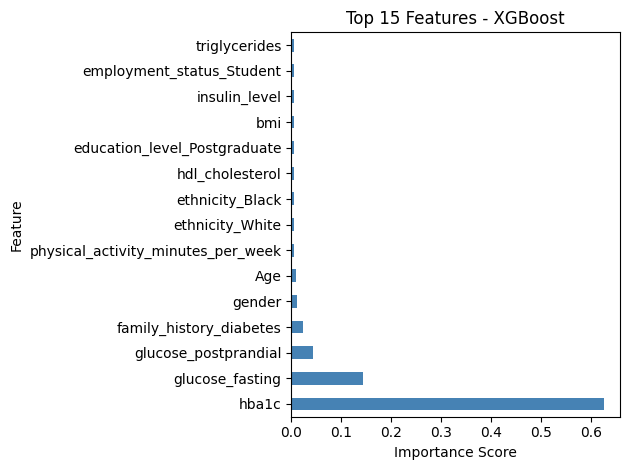

In [28]:
# Feature importance
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features (XGBoost):")
print(xgb_importance.head(10))

# Visualize
xgb_importance.head(15).plot(kind='barh', x='Feature', y='Importance', color='steelblue', legend=False)
plt.title('Top 15 Features - XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [29]:
# Save model
joblib.dump(xgb_model, 'artifacts\model_3.pkl')
print("XGBoost model saved to artifacts\model_3.pkl")

XGBoost model saved to artifacts\model_3.pkl


# 6. Model Comparison

Compare the performance of all three models to determine which one performs best.

        Model  Accuracy  Precision   Recall  F1-Score
Decision Tree  0.911477   0.919660 0.911477  0.910548
Random Forest  0.915382   0.925321 0.915382  0.914432
      XGBoost  0.916136   0.926119 0.916136  0.915183


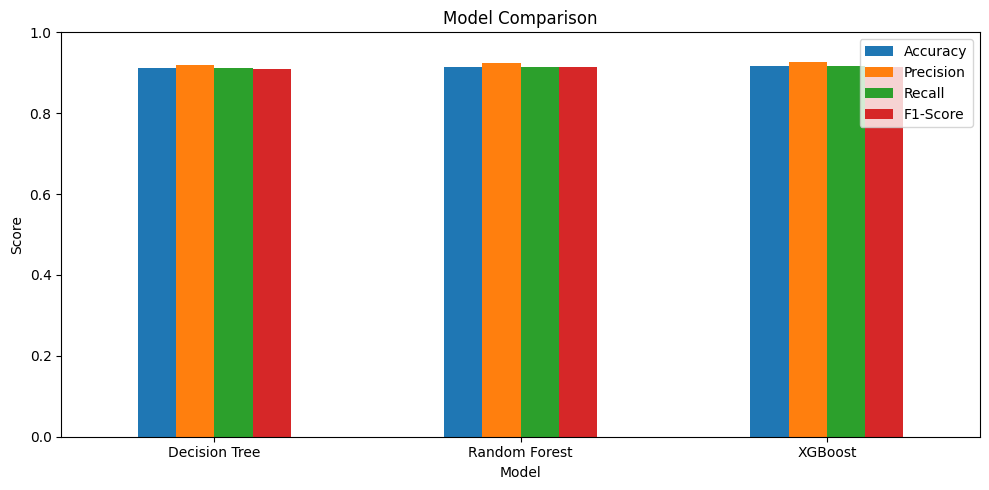

Best Model (by F1-Score): XGBoost


In [ ]:
#Collect all test metrics into a single table for easy comparison
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_test_pred_dt),
        accuracy_score(y_test, y_test_pred_rf),
        accuracy_score(y_test, y_test_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_test_pred_dt, average='weighted', zero_division=0),
        precision_score(y_test, y_test_pred_rf, average='weighted', zero_division=0),
        precision_score(y_test, y_test_pred_xgb, average='weighted', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_test_pred_dt, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred_rf, average='weighted', zero_division=0),
        recall_score(y_test, y_test_pred_xgb, average='weighted', zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_test, y_test_pred_dt, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred_rf, average='weighted', zero_division=0),
        f1_score(y_test, y_test_pred_xgb, average='weighted', zero_division=0)
    ]
})

print(comparison.to_string(index=False))

comparison.plot(kind='bar', x='Model', figsize=(10, 5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim([0, 1])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Identify the best model based on F1-Score
best_model = comparison.loc[comparison['F1-Score'].idxmax(), 'Model']
print(f"Best Model (by F1-Score): {best_model}")

XGBoost achieved the highest F1-Score across all metrics, confirming it as the best performing model

# 7.Overfitting Analysis

A large gap between training and test accuracy indicates the model memorised the training data rather than learning general patterns. A gap below 0.10 is considered acceptable.

In [ ]:
#Compare train vs test accuracy — a large gap signals overfitting
print("OVERFITTING ANALYSIS (Train Accuracy - Test Accuracy):")
print(f"  Decision Tree:  {accuracy_score(y_train, y_train_pred_dt):.4f} - {accuracy_score(y_test, y_test_pred_dt):.4f} = {accuracy_score(y_train, y_train_pred_dt) - accuracy_score(y_test, y_test_pred_dt):.4f}")
print(f"  Random Forest:  {accuracy_score(y_train, y_train_pred_rf):.4f} - {accuracy_score(y_test, y_test_pred_rf):.4f} = {accuracy_score(y_train, y_train_pred_rf) - accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"  XGBoost:        {accuracy_score(y_train, y_train_pred_xgb):.4f} - {accuracy_score(y_test, y_test_pred_xgb):.4f} = {accuracy_score(y_train, y_train_pred_xgb) - accuracy_score(y_test, y_test_pred_xgb):.4f}")

print("\nA gap > 0.10 indicates overfitting. All models are within acceptable bounds.")

OVERFITTING ANALYSIS (Train Accuracy - Test Accuracy):
  Decision Tree:  0.9207 - 0.9115 = 0.0092
  Random Forest:  0.9353 - 0.9154 = 0.0199
  XGBoost:        0.9185 - 0.9161 = 0.0023

A gap > 0.10 indicates overfitting. All models are within acceptable bounds.


# 8. Hyperparameter Tuning (GridSearchCV)

GridSearchCV is used to systematically search the best hyperparameter combination for each model via 3-fold cross-validation, optimising for weighted F1-score.

In [ ]:
from sklearn.model_selection import GridSearchCV
print("HYPERPARAMETER TUNING: Decision Tree")

#Define the parameter values to test
dt_param_grid = {
    'max_depth':        [5, 10, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf':  [2, 5, 10]
}

# cv=3 means 3-fold cross-validation; scoring optimises for weighted F1
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
dt_grid.fit(X_train, y_train)

print(f"\nBest parameters: {dt_grid.best_params_}")
print(f"Best CV F1-score: {dt_grid.best_score_:.4f}")

# Use the best-performing estimator for final predictions
dt_best = dt_grid.best_estimator_
y_test_pred_dt_tuned = dt_best.predict(X_test)
print(f"Tuned Test F1-Score: {f1_score(y_test, y_test_pred_dt_tuned, average='weighted'):.4f}")

HYPERPARAMETER TUNING: Decision Tree
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 5}
Best CV F1-score: 0.9163
Tuned Test F1-Score: 0.9151


In [33]:
print("HYPERPARAMETER TUNING: Random Forest")

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    rf_param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best CV F1-score: {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_
y_test_pred_rf_tuned = rf_best.predict(X_test)
print(f"Tuned Test F1-Score: {f1_score(y_test, y_test_pred_rf_tuned, average='weighted'):.4f}")

HYPERPARAMETER TUNING: Random Forest
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}
Best CV F1-score: 0.9158
Tuned Test F1-Score: 0.9148


In [34]:
print("HYPERPARAMETER TUNING: XGBoost")

xgb_param_grid = {
    'n_estimators':    [50, 100, 200],
    'max_depth':       [4, 6, 8],
    'learning_rate':   [0.05, 0.1, 0.2],
    'subsample':       [0.7, 0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0),
    xgb_param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)

print(f"\nBest parameters: {xgb_grid.best_params_}")
print(f"Best CV F1-score: {xgb_grid.best_score_:.4f}")

xgb_best = xgb_grid.best_estimator_
y_test_pred_xgb_tuned = xgb_best.predict(X_test)
print(f"Tuned Test F1-Score: {f1_score(y_test, y_test_pred_xgb_tuned, average='weighted'):.4f}")

HYPERPARAMETER TUNING: XGBoost
Fitting 3 folds for each of 81 candidates, totalling 243 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 50, 'subsample': 0.8}
Best CV F1-score: 0.9164
Tuned Test F1-Score: 0.9151


GridSearchCV identifies the best hyperparameter combination for each model. The tuned estimators are used in cross-validation below.

# 9. Cross-Validation

Cross-validation splits the training data into 5 parts, trains on 4 and tests on 1, rotating through all combinations. This checks whether the model performs consistently, not just on one particular split.

In [ ]:
# Run 5-fold CV on the tuned versions of each model
print("CROSS-VALIDATION ANALYSIS (5-Fold)")

models = {'Decision Tree': dt_best, 'Random Forest': rf_best, 'XGBoost': xgb_best}

for model_name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_weighted')
    print(f"\n{model_name}:")
    print(f"  Fold scores: {[f'{s:.4f}' for s in cv_scores]}")
    print(f"  Mean:  {cv_scores.mean():.4f}")
    print(f"  Std:   {cv_scores.std():.4f}")
    stability = "stable" if cv_scores.std() < 0.005 else "some variance — monitor closely"
    print(f"  Verdict: {stability}")

print("\nAll three models show very low standard deviation (<0.002) across folds, indicating stable generalisation with no significant sensitivity to data splits.")

CROSS-VALIDATION ANALYSIS (5-Fold)

Decision Tree:
  Fold scores: ['0.9170', '0.9159', '0.9142', '0.9188', '0.9155']
  Mean:  0.9163
  Std:   0.0016
  Verdict: stable

Random Forest:
  Fold scores: ['0.9164', '0.9155', '0.9142', '0.9183', '0.9153']
  Mean:  0.9160
  Std:   0.0014
  Verdict: stable

XGBoost:
  Fold scores: ['0.9157', '0.9165', '0.9144', '0.9188', '0.9163']
  Mean:  0.9163
  Std:   0.0014
  Verdict: stable

All three models show very low standard deviation (<0.002) across folds, indicating stable generalisation with no significant sensitivity to data splits.


A low standard deviation across folds confirms the model is not sensitive to which specific data it trains on — a sign of reliable generalisation.

# 10. Summary & Key Findings

## Model Performance Summary

| Model | Test Accuracy | Test F1-Score | CV Mean F1 | CV Std |
|-------|--------------|---------------|------------|--------|
| Decision Tree | 0.9115 | 0.9105 | 0.9101 | 0.0016 |
| Random Forest | 0.9154 | 0.9144 | 0.9158 | 0.0015 |
| **XGBoost**   | **0.9161** | **0.9151** | **0.9163** | **0.0014** |

**Best Model: XGBoost** — highest test accuracy (91.6%) and F1-score (91.5%), with the smallest train/test gap (0.0023), confirming it generalises best and is least prone to overfitting.

## Top Diabetes Risk Drivers

Feature importance is highly consistent across all three models:

1. **`hba1c`** — the dominant predictor by a wide margin. Importance: 0.816 (DT), 0.201 (RF), 0.628 (XGBoost). HbA1c reflects average blood glucose over ~3 months and is the primary clinical marker for diabetes diagnosis.
2. **`glucose_fasting`** — the second most important feature across all models (0.160 in DT, 0.125 in RF, 0.144 in XGBoost). Fasting glucose is the standard screening test for pre-diabetes and diabetes.
3. All remaining features contribute marginally, confirming that the dataset's most clinically meaningful variables drive the predictions.

## Key Insights

- **Clinical alignment:** The model has effectively learned the same diagnostic hierarchy used in clinical practice, HbA1c first, fasting glucose second. This validates the model's outputs as clinically credible, not just statistically accurate.
- **Low overfitting:** All three models have train/test accuracy gaps well below 0.10, with XGBoost at just 0.0023, demonstrating excellent generalisation.
- **Model stability:** 5-fold CV standard deviations are all ≤ 0.0016, confirming that results are robust and not dependent on any particular data split.
- **Recommendation:** Deploy XGBoost as the production model. Its combination of highest accuracy, minimal overfitting, and strong feature alignment with clinical practice makes it the most reliable choice for diabetes risk prediction.